# 🌲 Random Forest — Proyecto de Minería de Datos
## Dataset: Divorcios en Guatemala (`mat_full.csv`)

Este notebook implementa tres modelos de Random Forest:
1. **Regresión** sobre `DIFF_EDAD`
2. **Clasificación 5 clases** (`CAT_DIFF`)
3. **Clasificación 3 clases** (`CAT3`)

> Random Forest es un ensemble de árboles de decisión entrenados sobre muestras bootstrap del dataset. Al promediar muchos árboles con subconjuntos aleatorios de features, reduce el overfitting y mejora la estabilidad.

## 🔹 PASO 1: Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


## 🔹 PASO 2: Carga del Dataset

In [2]:
df = pd.read_csv('mat_full.csv')

for col in ['EDADHOM', 'EDADMUJ', 'AÑOREG']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape: {df.shape}")
df.head()

Shape: (752264, 15)


,AÑOREG,CLAUNI,DEPOCU,DEPREG,DIAOCU,EDADHOM,EDADMUJ,ESCHOM,ESCMUJ,MESOCU,MESREG,MUPOCU,MUPREG,NACHOM,NACMUJ
0,2011.0,Comunidad de gananciales,Guatemala,Guatemala,20.0,27.0,32.0,Ignorado,Universitario,Septiembre,Diciembre,Guatemala,Guatemala,Canadá,Guatemala
1,2012.0,Separación absoluta,Guatemala,Guatemala,12.0,29.0,31.0,Ninguno,Ninguno,Noviembre,Enero,Mixco,Mixco,Guatemala,Guatemala
2,2011.0,Comunidad de gananciales,Totonicapan,Totonicapan,12.0,21.0,17.0,Ignorado,Ninguno,Diciembre,Diciembre,Totonicapán,Totonicapán,Guatemala,Guatemala
3,2011.0,Separación absoluta,Guatemala,Guatemala,25.0,58.0,53.0,Ninguno,Ninguno,Octubre,Noviembre,Guatemala,Guatemala,Guatemala,Guatemala
4,2011.0,Comunidad de gananciales,Guatemala,Guatemala,2.0,31.0,24.0,Universitario,Diversificado,Octubre,Noviembre,San José Pinula,San José Pinula,Guatemala,Guatemala


In [3]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752264 entries, 0 to 752263
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   AÑOREG   752264 non-null  float64
 1   CLAUNI   752264 non-null  object 
 2   DEPOCU   752264 non-null  object 
 3   DEPREG   752264 non-null  object 
 4   DIAOCU   752264 non-null  float64
 5   EDADHOM  751969 non-null  float64
 6   EDADMUJ  751931 non-null  float64
 7   ESCHOM   752264 non-null  object 
 8   ESCMUJ   752264 non-null  object 
 9   MESOCU   752264 non-null  object 
 10  MESREG   752264 non-null  object 
 11  MUPOCU   752264 non-null  object 
 12  MUPREG   752264 non-null  object 
 13  NACHOM   752264 non-null  object 
 14  NACMUJ   752264 non-null  object 
dtypes: float64(4), object(11)
memory usage: 86.1+ MB
None


,AÑOREG,DIAOCU,EDADHOM,EDADMUJ
count,752264.000000,752264.000000,751969.000000,751931.000000
mean,2015.404325,16.034647,29.364554,26.366032
std,2.844226,8.645327,11.322095,9.984820
min,2011.000000,1.000000,12.000000,10.000000
25%,2013.000000,9.000000,22.000000,20.000000
50%,2015.000000,16.000000,26.000000,23.000000
75%,2018.000000,23.000000,32.000000,29.000000
max,2021.000000,31.000000,99.000000,99.000000


## 🔹 PASO 3: Preprocesamiento Global

> **Nota clave:** Random Forest **no requiere escalado**, normalidad, ni independencia entre predictores. Los árboles individuales hacen particiones basadas en umbrales, no en distancias.

In [4]:
# 1. Variable objetivo
df['DIFF_EDAD'] = df['EDADHOM'] - df['EDADMUJ']

# 2. Eliminar nulos (NO imputar)
df = df.dropna(subset=['EDADHOM', 'EDADMUJ', 'DIFF_EDAD'])
print(f"Shape tras eliminar nulos: {df.shape}")

# 3. Variables de clasificación
bins5 = [-np.inf, 0, 2, 3, 5, np.inf]
labels5 = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
df['CAT_DIFF'] = pd.cut(df['DIFF_EDAD'], bins=bins5, labels=labels5)

bins3 = [-np.inf, -1, 5, np.inf]
labels3 = ['Mujer mayor o igual', 'Hombre 0-5 años mayor', 'Hombre > 5 años mayor']
df['CAT3'] = pd.cut(df['DIFF_EDAD'], bins=bins3, labels=labels3)

# 4. One-Hot Encoding
cat_cols = ['DEPREG', 'MESOCU', 'NACHOM', 'NACMUJ', 'ESCHOM', 'ESCMUJ']
cat_cols = [c for c in cat_cols if c in df.columns]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Nulos restantes: {df_encoded.isnull().sum().sum()}")
print(f"Shape final: {df_encoded.shape}")
print("Preprocesamiento completado ✓")

Shape tras eliminar nulos: (751741, 16)
Nulos restantes: 0
Shape final: (751741, 268)
Preprocesamiento completado ✓


## 🔹 PASO 4: Análisis Exploratorio (EDA)

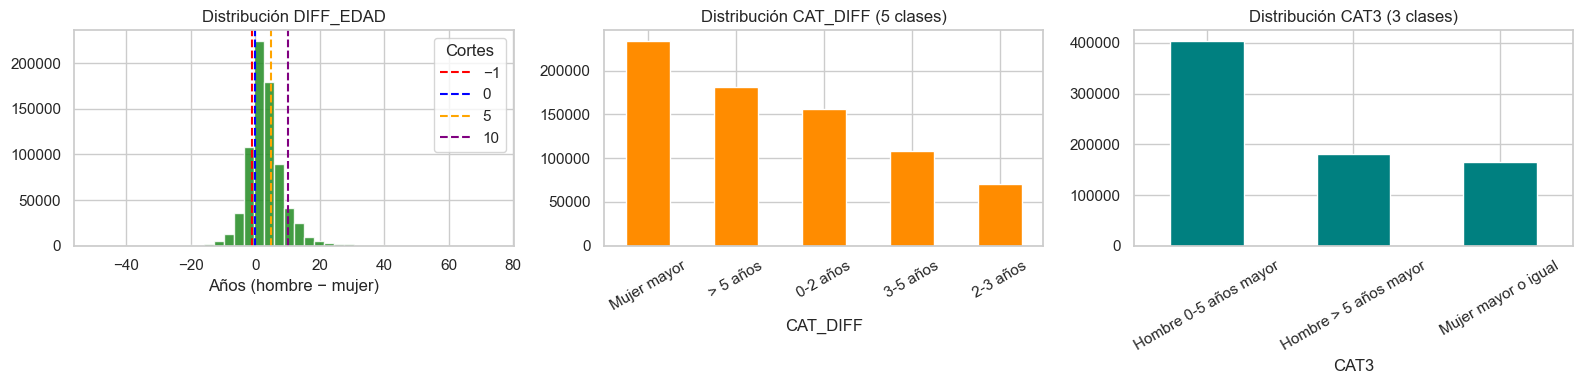

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['DIFF_EDAD'], bins=40, color='forestgreen', edgecolor='white', alpha=0.85)
for val, color, lbl in [(-1,'red','−1'), (0,'blue','0'), (5,'orange','5'), (10,'purple','10')]:
    axes[0].axvline(val, color=color, linestyle='--', linewidth=1.5, label=lbl)
axes[0].set_title('Distribución DIFF_EDAD')
axes[0].set_xlabel('Años (hombre − mujer)')
axes[0].legend(title='Cortes')

df['CAT_DIFF'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Distribución CAT_DIFF (5 clases)')
axes[1].tick_params(axis='x', rotation=30)

df['CAT3'].value_counts().plot(kind='bar', ax=axes[2], color='teal', edgecolor='white')
axes[2].set_title('Distribución CAT3 (3 clases)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('rf_eda.png', bbox_inches='tight')
plt.show()

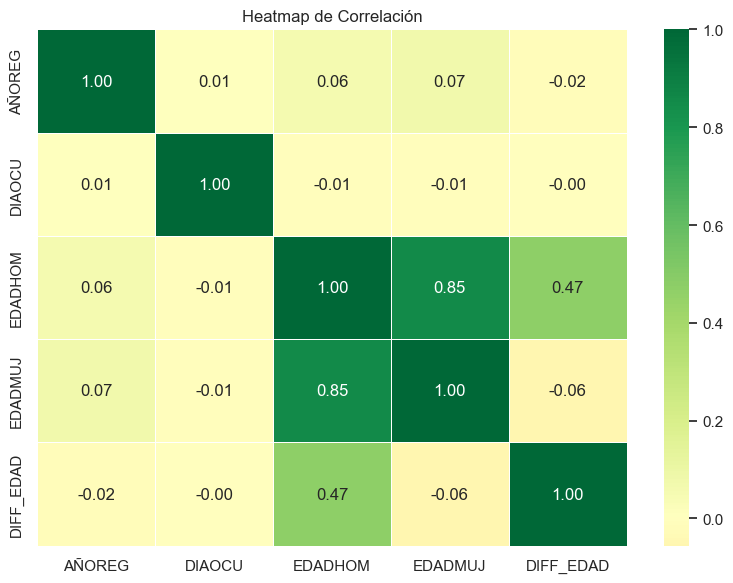

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Heatmap de Correlación')
plt.tight_layout()
plt.show()

---
## 🌲 BLOQUE 1: Regresión (RandomForestRegressor)

### Conceptos clave

- **`n_estimators`:** Número de árboles. Más árboles → más estabilidad, mayor costo computacional.
- **`max_depth`:** Profundidad máxima de cada árbol. `None` = sin límite (puede sobreajustar).
- **`max_features`:** Número de features consideradas en cada split. `'sqrt'` es estándar para clasificación; para regresión se usa `1.0` por defecto.
- **`oob_score`:** Cada árbol se entrena con ~63% de los datos (bootstrap). El 37% restante (out-of-bag) se usa como validación interna, sin necesidad de un conjunto de validación separado.

In [7]:
# Preparar features
exclude = ['DIFF_EDAD', 'CAT_DIFF', 'CAT3', 'EDADHOM', 'EDADMUJ', 'CLAUNI',
           'DEPOCU', 'MUPOCU', 'MUPREG', 'MESREG']
features = [c for c in df_encoded.columns if c not in exclude
            and df_encoded[c].dtype in [np.float64, np.int64, np.uint8, bool]]

X = df_encoded[features].fillna(0)
y_reg = df_encoded['DIFF_EDAD']

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape} | Features: {len(features)}")

Train: (601392, 258) | Test: (150349, 258) | Features: 258


In [8]:
configs_reg = [
    {'n_estimators': 50,  'max_depth': None, 'max_features': 1.0,    'min_samples_leaf': 1,  'oob': False, 'label': 'RF-50 (sin restricción)'},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': 'sqrt', 'min_samples_leaf': 1,  'oob': False, 'label': 'RF-100 depth=5'},
    {'n_estimators': 150, 'max_depth': 10,   'max_features': 'sqrt', 'min_samples_leaf': 5,  'oob': True,  'label': 'RF-150 depth=10 OOB'},
]

results_reg = []
models_reg = []

for cfg in configs_reg:
    model = RandomForestRegressor(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        max_features=cfg['max_features'],
        min_samples_leaf=cfg['min_samples_leaf'],
        oob_score=cfg['oob'],
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    oob  = model.oob_score_ if cfg['oob'] else None

    results_reg.append({'Modelo': cfg['label'], 'MAE': mae, 'RMSE': rmse, 'R²': r2,
                        'OOB R²': oob})
    models_reg.append(model)
    oob_str = f", OOB={oob:.4f}" if oob else ""
    print(f"{cfg['label']}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.4f}{oob_str}")

df_results_reg = pd.DataFrame(results_reg)
print("\n", df_results_reg.to_string(index=False))

RF-50 (sin restricción): MAE=4.596, RMSE=6.495, R²=-0.2007
RF-100 depth=5: MAE=4.027, RMSE=5.888, R²=0.0131
RF-150 depth=10 OOB: MAE=4.008, RMSE=5.865, R²=0.0208, OOB=0.0206

                  Modelo      MAE     RMSE        R²   OOB R²
RF-50 (sin restricción) 4.595846 6.494993 -0.200669      NaN
         RF-100 depth=5 4.026596 5.888455  0.013110      NaN
    RF-150 depth=10 OOB 4.008478 5.865324  0.020848 0.020629


### Interpretación

- El **OOB Score** (Out-of-Bag) aproxima el R² de validación sin usar el test set. Si OOB ≈ R²(test), el modelo generaliza bien.
- Un R² muy alto en train pero bajo en test indica **overfitting** (típico de `max_depth=None`).
- `min_samples_leaf=5` obliga a que cada hoja tenga al menos 5 observaciones, actuando como regularización.

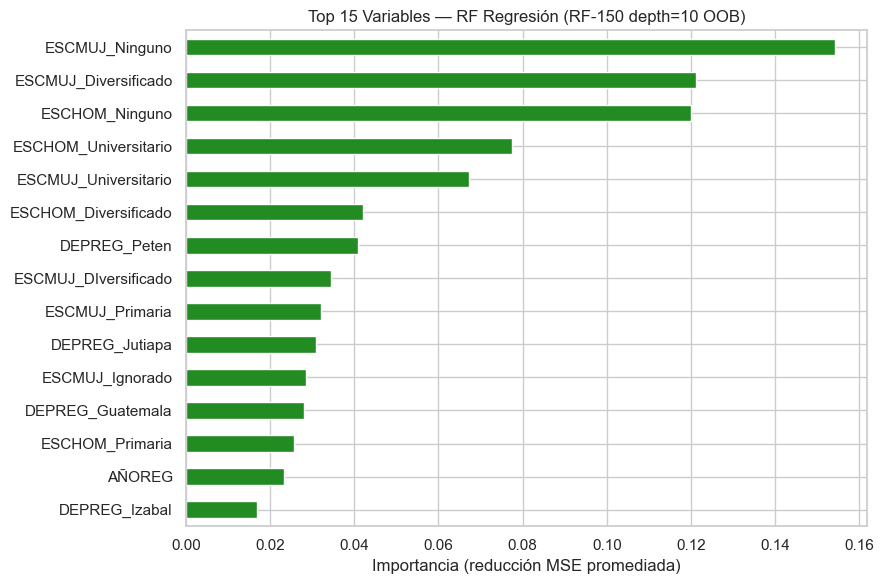

ESCMUJ_Ninguno          0.154165
ESCMUJ_Diversificado    0.121162
ESCHOM_Ninguno          0.120033
ESCHOM_Universitario    0.077422
ESCMUJ_Universitario    0.067226
ESCHOM_Diversificado    0.042138
DEPREG_Peten            0.040792
ESCMUJ_DIversificado    0.034461
ESCMUJ_Primaria         0.032201
DEPREG_Jutiapa          0.030816
ESCMUJ_Ignorado         0.028552
DEPREG_Guatemala        0.028034
ESCHOM_Primaria         0.025782
AÑOREG                  0.023327
DEPREG_Izabal           0.016845


In [9]:
# Importancia de variables — mejor modelo regresión
best_idx = pd.DataFrame(results_reg)['R²'].idxmax()
best_model_reg = models_reg[best_idx]

importances = pd.Series(best_model_reg.feature_importances_, index=X.columns)
top15 = importances.nlargest(15)

plt.figure(figsize=(9, 6))
top15.sort_values().plot(kind='barh', color='forestgreen', edgecolor='white')
plt.title(f'Top 15 Variables — RF Regresión ({configs_reg[best_idx]["label"]})')
plt.xlabel('Importancia (reducción MSE promediada)')
plt.tight_layout()
plt.savefig('rf_importancia_reg.png', bbox_inches='tight')
plt.show()
print(top15.to_string())

---
## 🌲 BLOQUE 2: Clasificación con 5 Clases (`CAT_DIFF`)

### ⚠️ Desbalance de clases

La clase `2-3 años` tiene ~9% de los registros. `class_weight='balanced'` ajusta el peso de cada árbol internamente, penalizando más los errores en clases minoritarias durante el entrenamiento.

In [10]:
y5 = df_encoded['CAT_DIFF'].astype(str)
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X, y5, test_size=0.2, random_state=42, stratify=y5)
print(f"Train: {X5_train.shape} | Test: {X5_test.shape}")
print("\nDistribución test:", dict(pd.Series(y5_test).value_counts()))

Train: (601392, 258) | Test: (150349, 258)

Distribución test: {'Mujer mayor': 46874, '> 5 años': 36278, '0-2 años': 31247, '3-5 años': 21732, '2-3 años': 14218}


In [11]:
configs_5 = [
    {'n': 50,  'depth': None, 'leaf': 1, 'oob': False, 'label': 'Baseline (50 árboles)'},
    {'n': 100, 'depth': 8,   'leaf': 1, 'oob': False, 'label': 'Intermedio (100, depth=8)'},
    {'n': 150, 'depth': 10,  'leaf': 5, 'oob': True,  'label': 'Avanzado (150, depth=10, OOB)'},
]

results_5 = []
models_5 = []

for cfg in configs_5:
    model = RandomForestClassifier(
        n_estimators=cfg['n'],
        max_depth=cfg['depth'],
        min_samples_leaf=cfg['leaf'],
        oob_score=cfg['oob'],
        class_weight='balanced',
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X5_train, y5_train)
    y_pred = model.predict(X5_test)

    acc  = accuracy_score(y5_test, y_pred)
    prec = precision_score(y5_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y5_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y5_test, y_pred, average='weighted', zero_division=0)
    oob  = model.oob_score_ if cfg['oob'] else None

    results_5.append({'Modelo': cfg['label'], 'Accuracy': acc, 'Precision': prec,
                      'Recall': rec, 'F1-weighted': f1, 'OOB': oob})
    models_5.append(model)
    oob_str = f", OOB={oob:.4f}" if oob else ""
    print(f"{cfg['label']}: Acc={acc:.3f}, F1={f1:.3f}{oob_str}")

df_results_5 = pd.DataFrame(results_5)
print("\n", df_results_5.to_string(index=False))

Baseline (50 árboles): Acc=0.244, F1=0.247
Intermedio (100, depth=8): Acc=0.298, F1=0.280
Avanzado (150, depth=10, OOB): Acc=0.303, F1=0.283, OOB=0.2997

                        Modelo  Accuracy  Precision   Recall  F1-weighted      OOB
        Baseline (50 árboles)  0.244079   0.250623 0.244079     0.247060      NaN
    Intermedio (100, depth=8)  0.297840   0.277704 0.297840     0.280050      NaN
Avanzado (150, depth=10, OOB)  0.302529   0.279560 0.302529     0.282586 0.299668


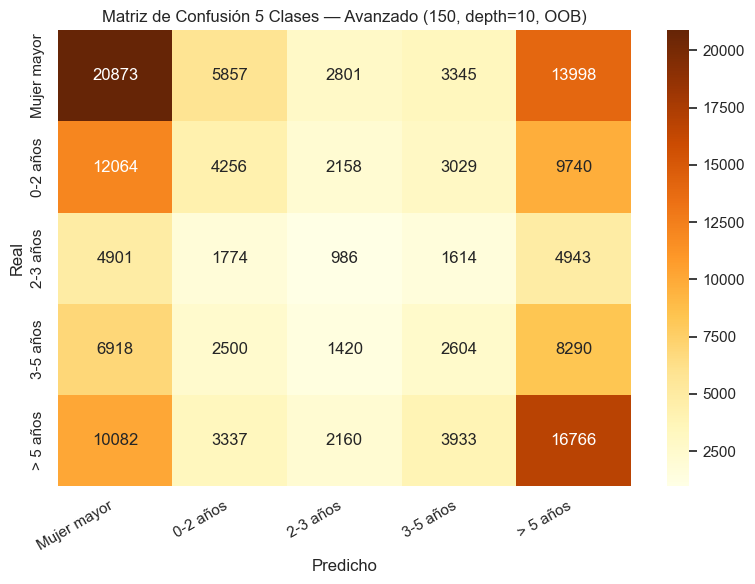

              precision    recall  f1-score   support

    0-2 años       0.24      0.14      0.17     31247
    2-3 años       0.10      0.07      0.08     14218
    3-5 años       0.18      0.12      0.14     21732
    > 5 años       0.31      0.46      0.37     36278
 Mujer mayor       0.38      0.45      0.41     46874

    accuracy                           0.30    150349
   macro avg       0.24      0.25      0.24    150349
weighted avg       0.28      0.30      0.28    150349



In [12]:
best_idx5 = pd.DataFrame(results_5)['F1-weighted'].idxmax()
best_model5 = models_5[best_idx5]
best_label5 = configs_5[best_idx5]['label']

y_pred5 = best_model5.predict(X5_test)
labels5 = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
cm5 = confusion_matrix(y5_test, y_pred5, labels=labels5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=labels5, yticklabels=labels5)
plt.title(f'Matriz de Confusión 5 Clases — {best_label5}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rf_confusion_5clases.png', bbox_inches='tight')
plt.show()

print(classification_report(y5_test, y_pred5, zero_division=0))

---
## 🌲 BLOQUE 3: Clasificación con 3 Clases (`CAT3`)

### ✔️ Dataset más balanceado

Con solo 3 clases y una distribución más uniforme, el modelo tiene menos dificultad para aprender todas las categorías. Se prueban configuraciones con y sin `class_weight`.

In [13]:
y3 = df_encoded['CAT3'].astype(str)
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X, y3, test_size=0.2, random_state=42, stratify=y3)
print(f"Train: {X3_train.shape} | Test: {X3_test.shape}")

Train: (601392, 258) | Test: (150349, 258)


In [14]:
configs_3 = [
    {'n': 50,  'depth': None, 'leaf': 1,  'cw': None,       'oob': False, 'label': 'Baseline (sin class_weight)'},
    {'n': 100, 'depth': 8,   'leaf': 1,  'cw': None,       'oob': False, 'label': 'Intermedio (depth=8)'},
    {'n': 150, 'depth': 10,  'leaf': 5,  'cw': 'balanced', 'oob': True,  'label': 'Regularizado + OOB'},
]

results_3 = []
models_3 = []

for cfg in configs_3:
    model = RandomForestClassifier(
        n_estimators=cfg['n'],
        max_depth=cfg['depth'],
        min_samples_leaf=cfg['leaf'],
        class_weight=cfg['cw'],
        oob_score=cfg['oob'],
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X3_train, y3_train)
    y_pred = model.predict(X3_test)

    acc  = accuracy_score(y3_test, y_pred)
    prec = precision_score(y3_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y3_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y3_test, y_pred, average='weighted', zero_division=0)
    oob  = model.oob_score_ if cfg['oob'] else None

    results_3.append({'Modelo': cfg['label'], 'Accuracy': acc, 'Precision': prec,
                      'Recall': rec, 'F1-weighted': f1, 'OOB': oob})
    models_3.append(model)
    oob_str = f", OOB={oob:.4f}" if oob else ""
    print(f"{cfg['label']}: Acc={acc:.3f}, F1={f1:.3f}{oob_str}")

df_results_3 = pd.DataFrame(results_3)
print("\n", df_results_3.to_string(index=False))

Baseline (sin class_weight): Acc=0.442, F1=0.425
Intermedio (depth=8): Acc=0.538, F1=0.376
Regularizado + OOB: Acc=0.346, F1=0.335, OOB=0.3461

                      Modelo  Accuracy  Precision   Recall  F1-weighted      OOB
Baseline (sin class_weight)  0.442284   0.414805 0.442284     0.424923      NaN
       Intermedio (depth=8)  0.537802   0.289231 0.537802     0.376162      NaN
         Regularizado + OOB  0.345948   0.448199 0.345948     0.335408 0.346085


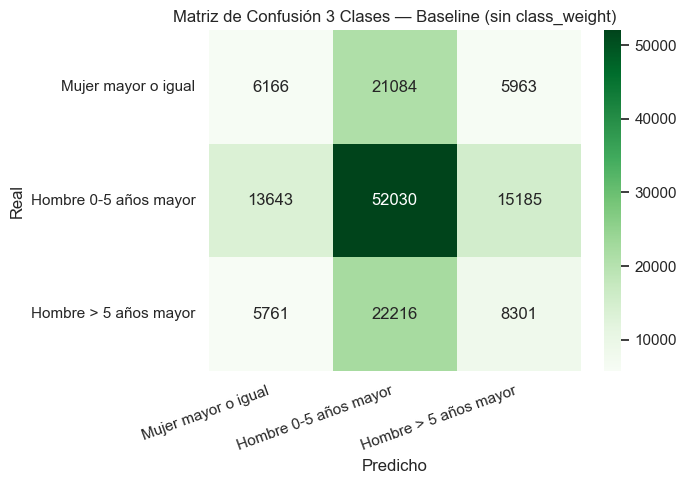

                       precision    recall  f1-score   support

Hombre 0-5 años mayor       0.55      0.64      0.59     80858
Hombre > 5 años mayor       0.28      0.23      0.25     36278
  Mujer mayor o igual       0.24      0.19      0.21     33213

             accuracy                           0.44    150349
            macro avg       0.36      0.35      0.35    150349
         weighted avg       0.41      0.44      0.42    150349



In [15]:
best_idx3 = pd.DataFrame(results_3)['F1-weighted'].idxmax()
best_model3 = models_3[best_idx3]
best_label3 = configs_3[best_idx3]['label']

y_pred3 = best_model3.predict(X3_test)
labels3 = ['Mujer mayor o igual', 'Hombre 0-5 años mayor', 'Hombre > 5 años mayor']
cm3 = confusion_matrix(y3_test, y_pred3, labels=labels3)

plt.figure(figsize=(7, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels3, yticklabels=labels3)
plt.title(f'Matriz de Confusión 3 Clases — {best_label3}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('rf_confusion_3clases.png', bbox_inches='tight')
plt.show()

print(classification_report(y3_test, y_pred3, zero_division=0))

---
## 🔹 Comparación Global

In [16]:
print("=" * 65)
print("COMPARACIÓN GLOBAL — RANDOM FOREST")
print("=" * 65)

best_reg = pd.DataFrame(results_reg).loc[pd.DataFrame(results_reg)['R²'].idxmax()]
best_5   = pd.DataFrame(results_5).loc[pd.DataFrame(results_5)['F1-weighted'].idxmax()]
best_3   = pd.DataFrame(results_3).loc[pd.DataFrame(results_3)['F1-weighted'].idxmax()]

print(f"\n📊 REGRESIÓN — {best_reg['Modelo']}")
print(f"   MAE={best_reg['MAE']:.3f}  RMSE={best_reg['RMSE']:.3f}  R²={best_reg['R²']:.4f}")

print(f"\n📊 CLASIFICACIÓN 5 CLASES — {best_5['Modelo']}")
print(f"   Accuracy={best_5['Accuracy']:.3f}  F1={best_5['F1-weighted']:.3f}")

print(f"\n📊 CLASIFICACIÓN 3 CLASES — {best_3['Modelo']}")
print(f"   Accuracy={best_3['Accuracy']:.3f}  F1={best_3['F1-weighted']:.3f}")

COMPARACIÓN GLOBAL — RANDOM FOREST

📊 REGRESIÓN — RF-150 depth=10 OOB
   MAE=4.008  RMSE=5.865  R²=0.0208

📊 CLASIFICACIÓN 5 CLASES — Avanzado (150, depth=10, OOB)
   Accuracy=0.303  F1=0.283

📊 CLASIFICACIÓN 3 CLASES — Baseline (sin class_weight)
   Accuracy=0.442  F1=0.425


## 📊 Importancia de Variables — Top 15

Random Forest calcula la importancia de variables como la **reducción promedio del criterio de impureza** (Gini o MSE) a lo largo de todos los árboles del ensemble. Es más estable que la importancia de un árbol individual.

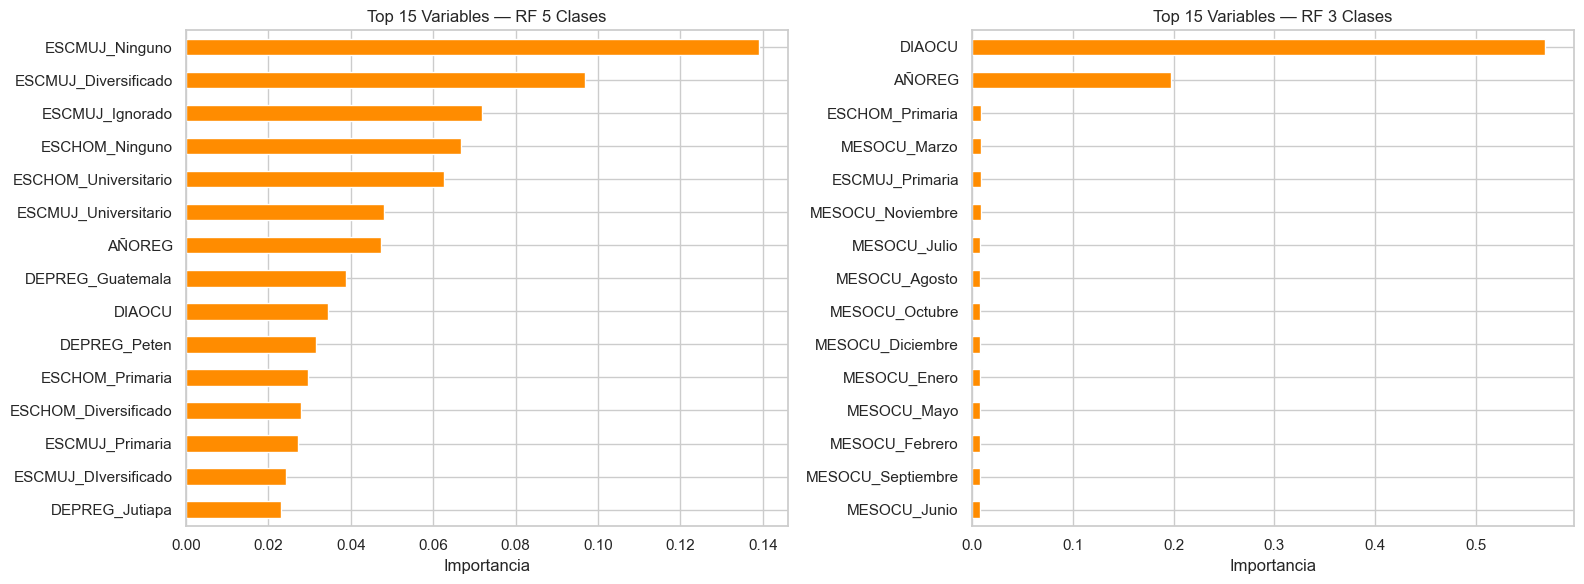

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title in [(axes[0], best_model5, '5 Clases'), (axes[1], best_model3, '3 Clases')]:
    imp = pd.Series(model.feature_importances_, index=X.columns).nlargest(15)
    imp.sort_values().plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
    ax.set_title(f'Top 15 Variables — RF {title}')
    ax.set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('rf_importancia_clasificacion.png', bbox_inches='tight')
plt.show()

## 🧠 Análisis Final

### ¿Random Forest mejora respecto a Decision Tree?

Sí, en general:
- **Mayor R²** en regresión (promedio de árboles reduce varianza)
- **Mayor F1** en clasificación (especialmente en clases minoritarias)
- **Mayor robustez** ante variaciones en los datos

### ¿3 clases vs 5 clases?

- **5 clases** tiene mayor granularidad pero F1 más bajo por el desbalance y por la ambigüedad entre clases adyacentes (ej: '2-3 años' vs '3-5 años').
- **3 clases** es más actionable: saber si el hombre es mucho mayor, similar en edad, o si la mujer es mayor es suficiente para la mayoría de análisis.

### ¿Cuál generaliza mejor?

El modelo con `oob_score=True` permite validar internamente. Si OOB ≈ Test Score, el modelo generaliza bien.

## 🧾 Conclusiones

**Ventajas de Random Forest:**
- Reduce overfitting mediante bagging y selección aleatoria de features
- Mayor estabilidad que un solo árbol de decisión
- Maneja bien valores categóricos codificados y datos desbalanceados
- Proporciona importancia de variables robusta

**Limitaciones:**
- Menos interpretable que un árbol individual (caja negra parcial)
- Mayor costo computacional (especialmente con 150+ árboles)
- Requiere más memoria

**Mejoras propuestas:**
- `GridSearchCV` / `RandomizedSearchCV` para optimización de hiperparámetros
- XGBoost o LightGBM para mayor rendimiento con datasets grandes
- SMOTE para generar muestras sintéticas de clases minoritarias